In [88]:
import pandas as pd

In [89]:
df = pd.read_csv('Mall_Customers.xls')

In [90]:
df.shape

(200, 5)

In [91]:
df = df.drop_duplicates()

In [92]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [93]:
df['Gender'] = df['Gender'].map({'Male':1,'Female': 0})

In [94]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [95]:
df.describe()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.440000,38.850000,60.560000,50.200000
std,57.879185,0.497633,13.969007,26.264721,25.823522
min,1.000000,0.000000,18.000000,15.000000,1.000000
25%,50.750000,0.000000,28.750000,41.500000,34.750000
50%,100.500000,0.000000,36.000000,61.500000,50.000000
75%,150.250000,1.000000,49.000000,78.000000,73.000000
max,200.000000,1.000000,70.000000,137.000000,99.000000


In [96]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [97]:
df = df.drop('CustomerID',axis=1)

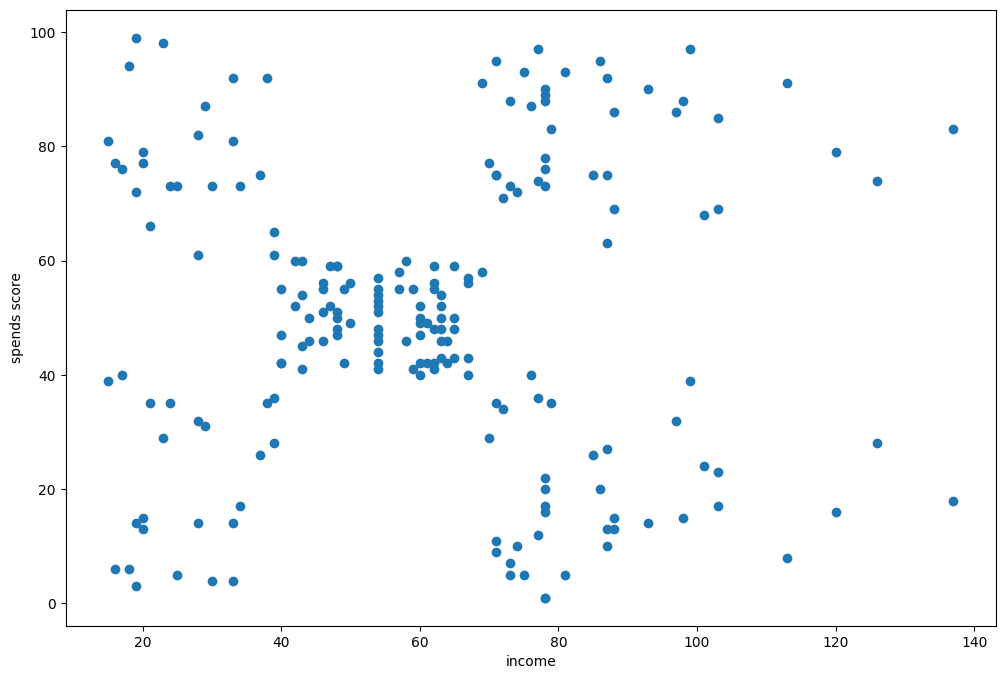

In [98]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,8))
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'])
plt.xlabel('income')
plt.ylabel('spends score')
plt.show()

In [99]:
df.corr()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Gender,1.000000,0.060867,0.056410,-0.058109
Age,0.060867,1.000000,-0.012398,-0.327227
Annual Income (k$),0.056410,-0.012398,1.000000,0.009903
Spending Score (1-100),-0.058109,-0.327227,0.009903,1.000000


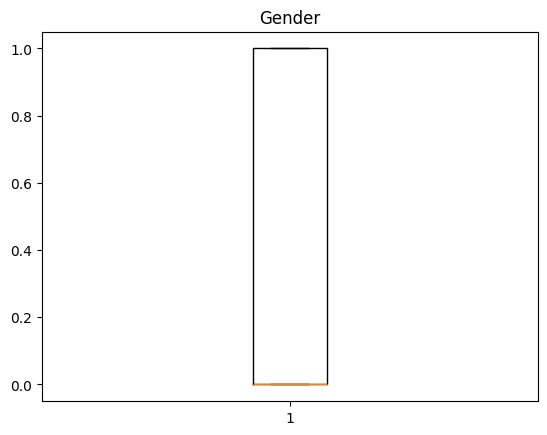

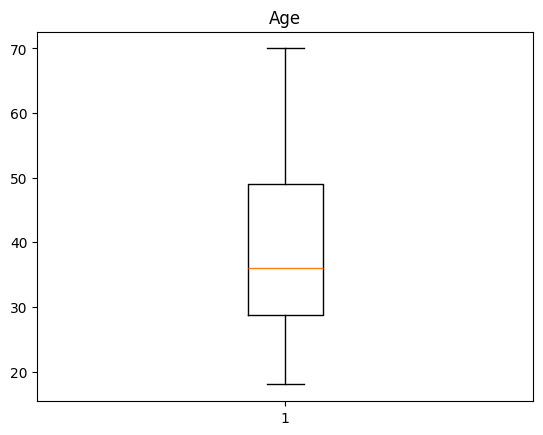

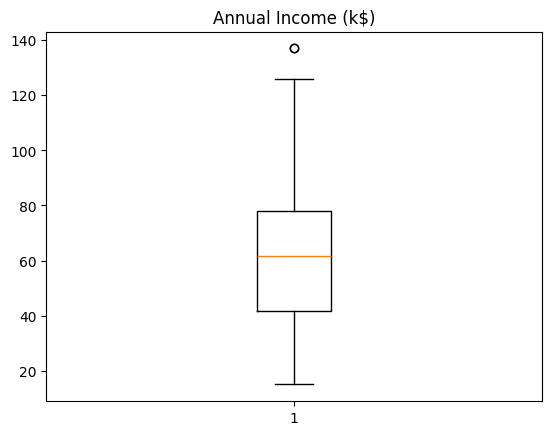

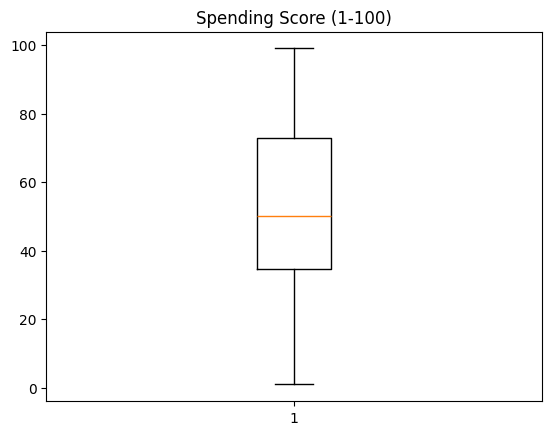

In [100]:
for col in df:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [101]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [102]:
X = df.drop('Gender',axis=1)

In [103]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     200 non-null    int64
 1   Annual Income (k$)      200 non-null    int64
 2   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB


In [104]:
from sklearn.preprocessing import StandardScaler


scale = StandardScaler()
X_scale = scale.fit_transform(X)



In [105]:
X_scale.shape

(200, 3)

In [106]:
from sklearn.cluster import KMeans

inertia = []
for k in range(2,21):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit_predict(X_scale)
    inertia.append(model.inertia_)

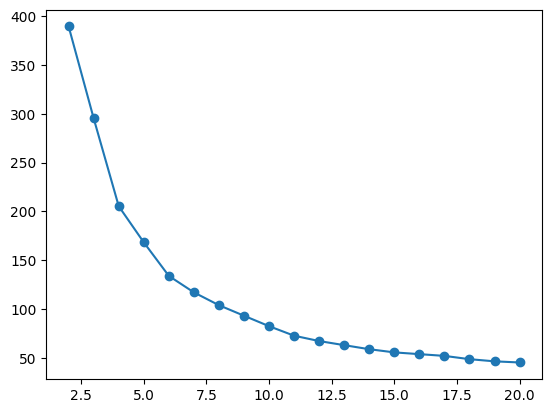

In [107]:
plt.plot(range(2,21), inertia, marker='o')
plt.show()

In [108]:
from sklearn.metrics import silhouette_score

score =[]
for k in range(2,21):
    kmean = KMeans(n_clusters=k,random_state=42, n_init=10)
    label = kmean.fit_predict(X_scale)
    score.append(silhouette_score(X_scale, label))
    

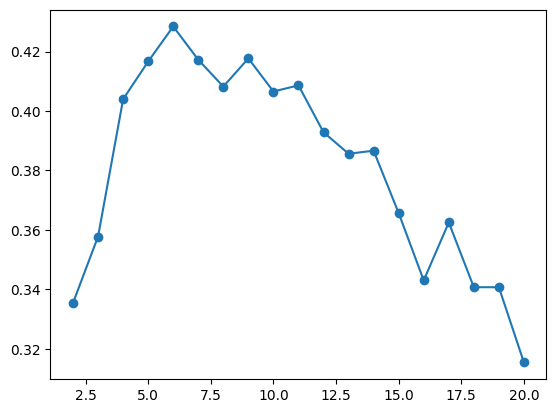

In [109]:
plt.plot(range(2,21), score, marker='o')
plt.show()

In [110]:
model = KMeans(n_clusters=5, random_state=42, n_init=10)
label = model.fit_predict(X_scale)

df['Cluster'] = label

In [111]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,1
1,1,21,15,81,1
2,0,20,16,6,0
3,0,23,16,77,1
4,0,31,17,40,1


In [112]:
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

cluster_summary = df.groupby('Cluster')[features].mean()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


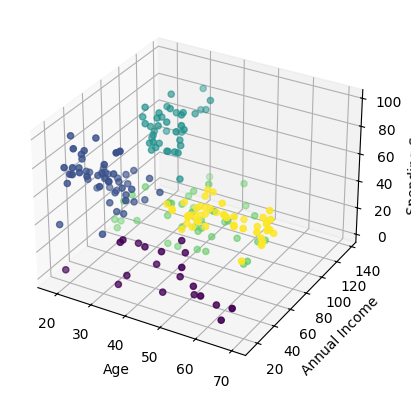

In [113]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending Score')

plt.show()